In [6]:
import sys
sys.path.append(r"C:\Users\Akash\Desktop\stock-forecasting\src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from data_loader import load_all
from lstm_model import (
    prepare_lstm_data,
    split_and_scale,
    build_lstm_model,
    train_lstm,
    evaluate_lstm
)

import tensorflow as tf
print("✓ TensorFlow version:", tf.__version__)

✓ TensorFlow version: 2.21.0


In [7]:
data_raw = load_all(save=False)
print("Loaded:", list(data_raw.keys()))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed

Loaded: ['AAPL', 'RELIANCE.NS', 'INFY.NS']


In [8]:
ticker   = "AAPL"
LOOKBACK = 60   # use last 60 trading days to predict next day

close_df = prepare_lstm_data(data_raw[ticker], ticker)
print(f"\n{ticker} close prices shape: {close_df.shape}")

X_train, y_train, X_test, y_test, scaler, split_idx = split_and_scale(
    close_df, test_ratio=0.2, lookback=LOOKBACK
)

model = build_lstm_model(lookback=LOOKBACK)


AAPL close prices shape: (1509, 1)
X_train: (1147, 60, 1) | y_train: (1147,)
X_test : (302, 60, 1)  | y_test : (302,)


c:\Users\Akash\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = train_lstm(model, X_train, y_train, epochs=50, batch_size=32)
print("\n✓ Training complete")

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - loss: 0.0181 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0026 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0019 - val_loss: 6.2366e-04 - learning_rate: 0.0010
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0016 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0017 - val_loss: 8.7966e-04 - learning_rate: 0.0010
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0015 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0014 - val_loss: 9.2456e-04 - learning_rate: 0.0010
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0012
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0013 - val_loss: 0.0014 - learnin

In [10]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    y=history.history["loss"], name="Train Loss", line=dict(color="#2196F3", width=2)
))
fig.add_trace(go.Scatter(
    y=history.history["val_loss"], name="Val Loss", line=dict(color="#FF5722", width=2)
))
fig.update_layout(
    title=f"{ticker} — LSTM Training vs Validation Loss",
    xaxis_title="Epoch",
    yaxis_title="MSE Loss",
    height=400,
    template="plotly_white"
)
fig.show()

In [11]:
predictions, actual, metrics = evaluate_lstm(model, X_test, y_test, scaler)

print(f"\n📊 LSTM Metrics — {ticker}")
print(f"  MAE  : ${metrics['MAE']}")
print(f"  RMSE : ${metrics['RMSE']}")
print(f"  MAPE : {metrics['MAPE']}%")

# Build date index for test period
test_dates = close_df.index[split_idx:]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=close_df.index[:split_idx],
    y=close_df["Close"].values[:split_idx],
    name="Train Data", line=dict(color="#888", width=1)
))
fig.add_trace(go.Scatter(
    x=test_dates, y=actual.flatten(),
    name="Actual Price", line=dict(color="#2196F3", width=2)
))
fig.add_trace(go.Scatter(
    x=test_dates, y=predictions.flatten(),
    name="LSTM Forecast", line=dict(color="#FF9800", width=2)
))
fig.update_layout(
    title=f"{ticker} — LSTM Predicted vs Actual Price",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    height=500,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step

📊 LSTM Metrics — AAPL
  MAE  : $6.6535
  RMSE : $8.3852
  MAPE : 3.1763%


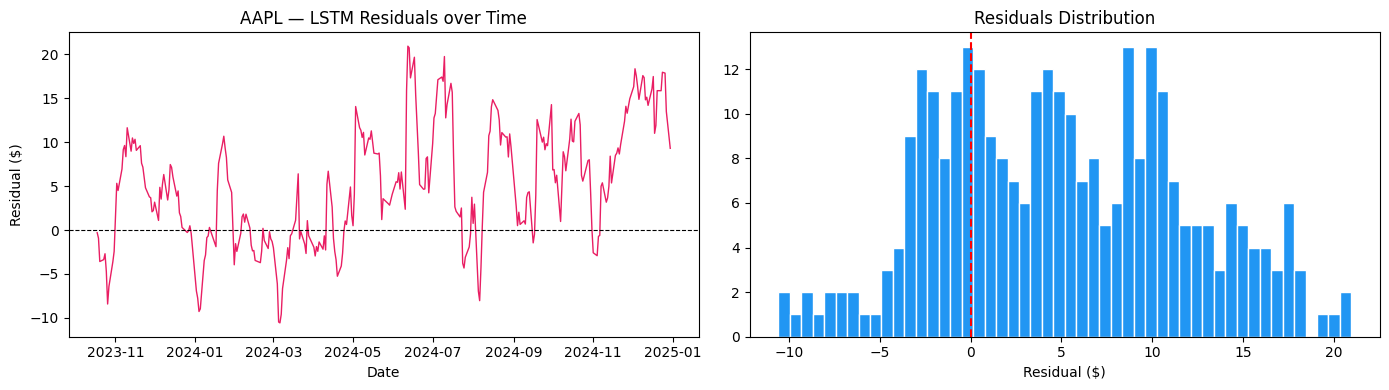

Mean residual: $5.0050
Std  residual: $6.7276


In [12]:
residuals = actual.flatten() - predictions.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_dates, residuals, color="#E91E63", linewidth=1)
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title(f"{ticker} — LSTM Residuals over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual ($)")

axes[1].hist(residuals, bins=50, color="#2196F3", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Distribution")
axes[1].set_xlabel("Residual ($)")

plt.tight_layout()
plt.show()

print(f"Mean residual: ${residuals.mean():.4f}")
print(f"Std  residual: ${residuals.std():.4f}")

In [13]:
import os
os.makedirs("models", exist_ok=True)
model.save(f"models/lstm_{ticker}.keras")
print(f"✓ Model saved to models/lstm_{ticker}.keras")

✓ Model saved to models/lstm_AAPL.keras


In [14]:
lstm_results = {}

for ticker, df in data_raw.items():
    print(f"\n{'='*45}")
    print(f"Training LSTM on {ticker}...")
    close_df = prepare_lstm_data(df, ticker)
    X_train, y_train, X_test, y_test, scaler, split_idx = split_and_scale(close_df)
    m = build_lstm_model()
    train_lstm(m, X_train, y_train, epochs=50, batch_size=32)
    _, _, metrics = evaluate_lstm(m, X_test, y_test, scaler)
    lstm_results[ticker] = metrics
    m.save(f"models/lstm_{ticker.replace('.','_')}.keras")
    print(f"  MAE: ${metrics['MAE']} | RMSE: ${metrics['RMSE']} | MAPE: {metrics['MAPE']}%")

summary = pd.DataFrame(lstm_results).T
summary.index.name = "Ticker"
print("\n====== LSTM Results Summary ======")
print(summary.to_string())
summary.to_csv("data/lstm_metrics.csv")


Training LSTM on AAPL...
X_train: (1147, 60, 1) | y_train: (1147,)
X_test : (302, 60, 1)  | y_test : (302,)


c:\Users\Akash\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0324 - val_loss: 5.3548e-04 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0038 - val_loss: 5.0474e-04 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0026 - val_loss: 5.4748e-04 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0026 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0023 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 6/50
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0025
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0025 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0022 - val_loss: 0.0028 - learning_rate: 5.0000e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0019 - val_loss: 0.0022 - lea

In [16]:
prophet_path = "data/prophet_metrics.csv"
lstm_path = "data/lstm_metrics.csv"

# Load or create fallback for prophet metrics
if os.path.exists(prophet_path):
	prophet_metrics = pd.read_csv(prophet_path, index_col="Ticker")
else:
	print(f"⚠️ {prophet_path} not found — creating empty Prophet metrics (NaN)")
	# determine index from available sources
	if os.path.exists(lstm_path):
		idx = pd.read_csv(lstm_path, index_col="Ticker").index
	elif "summary" in globals():
		idx = summary.index
	else:
		idx = []
	prophet_metrics = pd.DataFrame(index=idx, columns=["MAE", "RMSE", "MAPE"], dtype=float)

# Load or fallback for lstm metrics
if os.path.exists(lstm_path):
	lstm_metrics = pd.read_csv(lstm_path, index_col="Ticker")
elif "summary" in globals():
	lstm_metrics = summary.copy()
else:
	print(f"⚠️ {lstm_path} not found — creating empty LSTM metrics (NaN)")
	lstm_metrics = pd.DataFrame(index=prophet_metrics.index, columns=["MAE", "RMSE", "MAPE"], dtype=float)

prophet_metrics.columns = [f"Prophet_{c}" for c in prophet_metrics.columns]
lstm_metrics.columns    = [f"LSTM_{c}"    for c in lstm_metrics.columns]

comparison = pd.concat([prophet_metrics, lstm_metrics], axis=1)
# keep expected column order when present
cols = ["Prophet_MAE","LSTM_MAE","Prophet_RMSE","LSTM_RMSE","Prophet_MAPE","LSTM_MAPE"]
cols_present = [c for c in cols if c in comparison.columns]
comparison = comparison[cols_present]

print("\n====== Prophet vs LSTM — Final Comparison ======")
print(comparison.to_string())

os.makedirs("data", exist_ok=True)
comparison.to_csv("data/final_comparison.csv")
print("\n✓ Saved to data/final_comparison.csv")

⚠️ data/prophet_metrics.csv not found — creating empty Prophet metrics (NaN)

====== Prophet vs LSTM — Final Comparison ======
             Prophet_MAE  LSTM_MAE  Prophet_RMSE  LSTM_RMSE  Prophet_MAPE  LSTM_MAPE
Ticker                                                                              
AAPL                 NaN    9.9455           NaN    12.2312           NaN     4.6820
RELIANCE.NS          NaN   33.4403           NaN    40.7287           NaN     2.3844
INFY.NS              NaN   59.2081           NaN    72.3276           NaN     3.6367

✓ Saved to data/final_comparison.csv
